<center><table>
    <tr>
        <th><img src="./figure/INL1.png" align="middle" height="80"/></th>
        <th><img src="./figure/MIT1.png" align="middle" height="80"/></th>
        <th><img src="./figure/ANL.png" align="middle" height="80"/></th>
    </tr>
</table></center>

# <center>Cost Reduction Framework Showcase</center>

This notebook uses the new `src/crf` API in ACCERT to run deterministic CRF scenarios, inspect the returned tables, and generate dashboard figures.

## 1. Imports and Path Setup

In [1]:
from pathlib import Path
import os
import sys
import tempfile
import warnings

os.environ.setdefault("MPLCONFIGDIR", tempfile.gettempdir())

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

cwd = Path.cwd().resolve()
repo_root = next(path for path in [cwd, *cwd.parents] if (path / "src" / "crf").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from crf.model.schedule import build_schedule_timeline

from crf import (
    levers_to_dataframe,
    occ_reduction_from_foak_to_noak,
    print_scenario_result,
    results_to_dataframe,
    run_one_scenario,
    save_dashboard,
    waterfall_to_dataframe,
)

output_dir = repo_root / "tutorial"
output_dir.mkdir(exist_ok=True)
print(f"Using ACCERT repository: {repo_root}")

def show_image(path, figsize=(12, 8)):
    image = plt.imread(path)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    ax.axis("off")
    return fig


Using ACCERT repository: /Users/jia.zhou/projects/ACCERT


## Individual Plot Helpers

These helper functions show each dashboard panel as a larger standalone figure for easier notebook inspection.

In [2]:
def _style_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.25)


def plot_capital_cost_panel(result, figsize=(10, 5)):
    df = results_to_dataframe(result)
    x = df["Plant number"]
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(x - 0.18, df["TCI"], width=0.36, label="10-60 - Total Capital Investment (TCI)", color="tab:green")
    ax.bar(x + 0.18, df["OCC"], width=0.36, label="10-50 - Overnight Capital Cost (OCC)", color="tab:blue")
    if df["Net OCC"].notna().any():
        ax.plot(x, df["Net OCC"], marker="o", linestyle="--", linewidth=1.2, label="Net OCC after ITC")
    if df["NCI"].notna().any():
        ax.plot(x, df["NCI"], marker="o", linestyle="--", linewidth=1.2, label="Net Capital Investment")
    ax.set_title("Capital Cost: OCC and TCI")
    ax.set_xlabel("Plant number")
    ax.set_ylabel("$/kWe")
    ax.legend(fontsize=9)
    _style_ax(ax)
    return fig


def plot_duration_panel(result, figsize=(10, 5)):
    df = results_to_dataframe(result)
    x = df["Plant number"]
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(x, df["Construction duration"], label="Construction", color="#ff8c2a")
    ax.bar(x, df["Startup duration"], bottom=df["Construction duration"], label="Startup", color="#8b63a9")
    ax.set_title("Total Construction Duration")
    ax.set_xlabel("Plant number")
    ax.set_ylabel("Months")
    ax.legend(fontsize=9)
    _style_ax(ax)
    return fig


def plot_tci_breakdown_panel(result, figsize=(10, 5)):
    df = results_to_dataframe(result)
    x = df["Plant number"]
    columns = [
        ("Preconstruction costs", "10 - Preconstruction", "#4c78a8"),
        ("Direct costs", "20 - Direct", "#72b7b2"),
        ("Indirect costs", "30 - Indirect", "#54a24b"),
        ("Supplementary costs", "50 - Supplementary", "#b279a2"),
        ("Financing costs", "60 - Financing", "#ff9da6"),
    ]
    fig, ax = plt.subplots(figsize=figsize)
    bottom = np.zeros(len(df))
    for column, label, color in columns:
        values = df[column].fillna(0).astype(float).to_numpy()
        ax.bar(x, values, bottom=bottom, label=label, color=color)
        bottom += values
    ax.set_title("10-60 - TCI Breakdown")
    ax.set_xlabel("Plant number")
    ax.set_ylabel("$/kWe")
    ax.legend(fontsize=9)
    _style_ax(ax)
    return fig


def plot_timeline_panel(result, figsize=(11, 5)):
    df = results_to_dataframe(result)
    plants = df["Plant number"].astype(int).to_numpy()
    durations = df["Construction duration"].astype(float).to_numpy()
    startup = df["Startup duration"].fillna(0).astype(float).to_numpy()
    timeline = build_schedule_timeline(
        {"staggering_ratio": result.get("staggering_ratio", 0.75), "reactor_type": result.get("reactor_type", "")},
        plants,
        durations,
        startup,
    )
    start_years = timeline["construction_start_month"] / 12
    duration_years = timeline["construction_duration_months"] / 12
    startup_years = timeline["startup_duration_months"] / 12
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(plants, duration_years, left=start_years, height=0.64, color="#ff8c2a", edgecolor="black", label="Construction")
    ax.barh(plants, startup_years, left=start_years + duration_years, height=0.64, color="#8b63a9", edgecolor="black", label="Startup")
    ax.set_title("Sequential Construction Timeline")
    ax.set_xlabel("Time (Years)")
    ax.set_ylabel("Reactor Number")
    ax.set_yticks(plants)
    ax.set_ylim(plants.max() + 0.7, plants.min() - 0.7)
    ax.set_xlim(0, float(np.nanmax(start_years + duration_years + startup_years)) * 1.05)
    ax.grid(True, axis="x", alpha=0.35)
    ax.legend(fontsize=9)
    return fig


def plot_occ_components_panel(result, figsize=(10, 5)):
    df = results_to_dataframe(result)
    x = df["Plant number"]
    columns = [
        ("Direct costs: equipment", "20 - Direct: Equipment", "#72b7b2"),
        ("Direct costs: material", "20 - Direct: Material", "#f58518"),
        ("Direct costs: labor", "20 - Direct: Labor", "#e45756"),
        ("Indirect costs", "30 - Indirect", "#54a24b"),
        ("Supplementary costs", "50 - Supplementary", "#b279a2"),
    ]
    fig, ax = plt.subplots(figsize=figsize)
    bottom = np.zeros(len(df))
    for column, label, color in columns:
        values = df[column].fillna(0).astype(float).to_numpy()
        ax.bar(x, values, bottom=bottom, label=label, color=color)
        bottom += values
    ax.set_title("10-50 - OCC Components")
    ax.set_xlabel("Plant number")
    ax.set_ylabel("$/kWe")
    ax.legend(fontsize=9)
    _style_ax(ax)
    return fig


def plot_waterfall_panel(result, figsize=(11, 5)):
    waterfall = waterfall_to_dataframe(result)
    foak_occ = float(waterfall.iloc[0]["cumulative_occ"])
    x = np.arange(len(waterfall))
    labels = ["\n".join(str(label).replace("\n", " ").split()) for label in waterfall["label"]]
    labels = ["\n".join(label.split()[:3]) if len(label) > 18 else label for label in labels]
    bottoms, heights, colors, pct_labels = [], [], [], []
    noak_reduction = occ_reduction_from_foak_to_noak(result)
    for _, row in waterfall.iterrows():
        if row["kind"] == "total":
            total = float(row["cumulative_occ"])
            bottoms.append(0)
            heights.append(total)
            colors.append("#4c78a8")
            pct_labels.append("100%" if row.name == 0 else f"{noak_reduction:.1f}% lower")
        else:
            current = float(row["cumulative_occ"])
            change = float(row["absolute_change"])
            previous = current - change
            bottoms.append(previous if change >= 0 else current)
            heights.append(abs(change))
            colors.append("#f58518" if change >= 0 else "#54a24b")
            pct_labels.append(f"{change / foak_occ * 100:+.1f}%")
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(x, heights, bottom=bottoms, color=colors, width=0.72)
    for idx in range(len(waterfall) - 1):
        y = float(waterfall.iloc[idx]["cumulative_occ"])
        ax.plot([idx + 0.36, idx + 1 - 0.36], [y, y], color="#777777", linewidth=0.8)
    max_y = max(bottom + height for bottom, height in zip(bottoms, heights))
    for idx, (bottom, height, label) in enumerate(zip(bottoms, heights, pct_labels)):
        if height > 0:
            ax.text(idx, bottom + height / 2, label, ha="center", va="center", fontsize=8, fontweight="bold", color="white")
    ax.set_title("% OCC Reduction from FOAK to NOAK")
    ax.set_ylabel("OCC ($/kWe)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0, max_y * 1.12)
    _style_ax(ax)
    return fig

## 2. Scenario Inputs

The dictionaries below mirror the Python tutorial files and can be edited directly.

In [3]:
def base_config(reactor_type):
    startup = 28 if reactor_type == "AP1000" else 16
    return {
        "reactor_type": reactor_type,
        "f_22": 250_000_000,
        "f_2321": 150_000_000,
        "land_cost_per_acre_0": 22_000,
        "startup_0": startup,
        "staggering_ratio": 0.75,
    }


def base_levers(reactor_type):
    common = {
        "num_orders": 10 if reactor_type == "AP1000" else 13,
        "num_NOAK": 8,
        "itc_percent": 0,
        "n_itc": 0,
        "interest_percent": 6,
        "design_completion_percent": 70 if reactor_type == "AP1000" else 80,
        "design_maturity": 1,
        "proc_exp": 0.5,
        "N_proc": 3,
        "ce_exp": 0.5 if reactor_type == "AP1000" else 1.0,
        "N_cons": 5,
        "ae_exp": 0.5,
        "N_AE": 4,
        "standardization_percent": 80,
        "modularity_code": 1,
        "bop_grade_code": 1,
        "rb_grade_code": 0,
    }
    if reactor_type == "AP1000":
        common.update({"modularity_code": 0, "bop_grade_code": 0, "rb_grade_code": 0})
    return common

### The Cost reduction framework: levers and variables impact the costs as shown in the figure (below)

<center><table>
    <tr>
        <th><img src="./figure/framework_diagram.png",align="middle",height="10000"/></th>
    </tr>
</table>
</center>

## 3. Run One AP1000 Scenario

In [4]:
config = base_config("AP1000")
levers = base_levers("AP1000")

result = run_one_scenario(config, levers)
print_scenario_result(result)

Results by plant number:

 Plant_number      OCC      TCI  duration  STAUP   D10s    D20s    D30s  D50s    D60s  D20_equip  D20_mat  D20_labor
            1 15102.81 18234.07     91.00  28.00 124.67 7038.51 7864.84 74.79 3131.26    3106.85   755.46    3176.20
            2  8386.78  9565.41     68.30  19.60 124.67 4566.29 3651.12 44.70 1178.63    2298.79   503.34    1764.15
            3  6446.14  7176.45     59.88  15.91 124.67 3781.39 2504.07 36.01  730.31    2056.40   423.47    1301.52
            4  5148.35  5656.50     55.16  13.72 124.67 3193.25 1800.24 30.20  508.15    1834.31   361.64     997.30
            5  4594.40  5000.74     52.18  12.23 124.67 2947.74 1494.27 27.71  406.34    1759.01   335.27     853.46
            6  4419.57  4775.83     50.01  11.14 124.67 2879.57 1388.40 26.93  356.25    1751.70   324.78     803.09
            7  4280.91  4598.93     48.24  10.29 124.67 2824.55 1305.37 26.31  318.03    1745.56   316.17     762.83
            8  4167.11  4461.45     46

## 4. Dashboard Figure

Set `show_levers=False` to hide the top lever table.

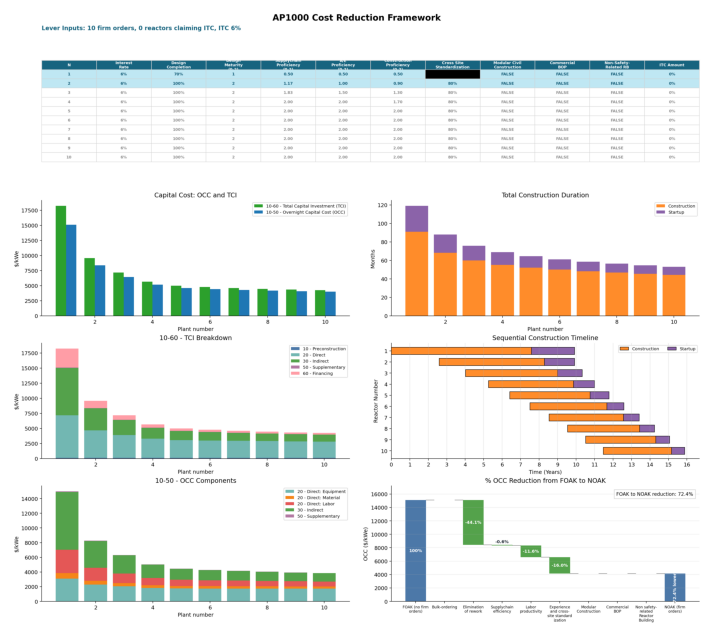

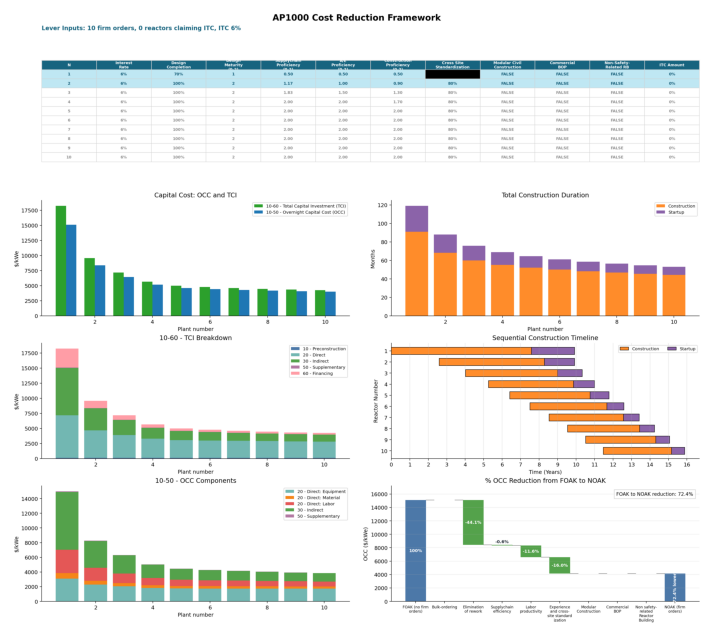

In [5]:
dashboard_path = output_dir / "crf_showcase_ap1000_dashboard.png"
save_dashboard(result, dashboard_path, title="AP1000 Cost Reduction Framework", show_levers=True)
show_image(dashboard_path)

## 5. Large Individual Dashboard Panels

Run these cells when the full dashboard is too compact. Each figure is shown at notebook-friendly size.

### Capital Cost

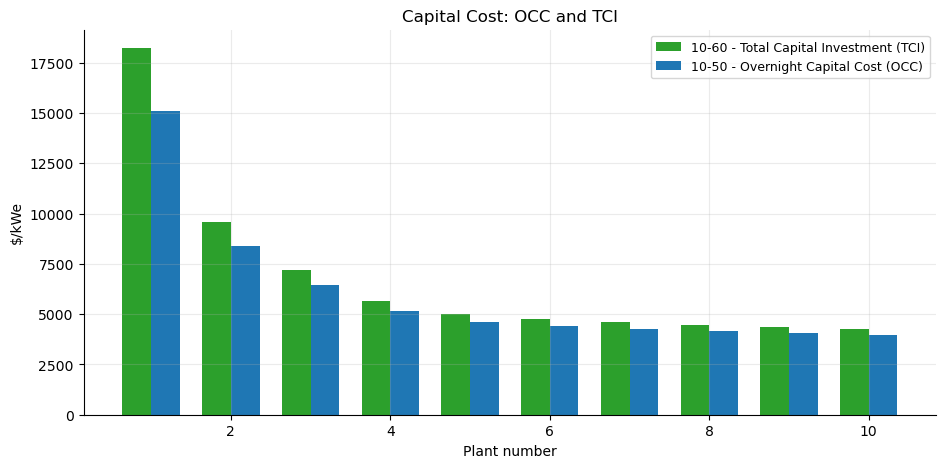

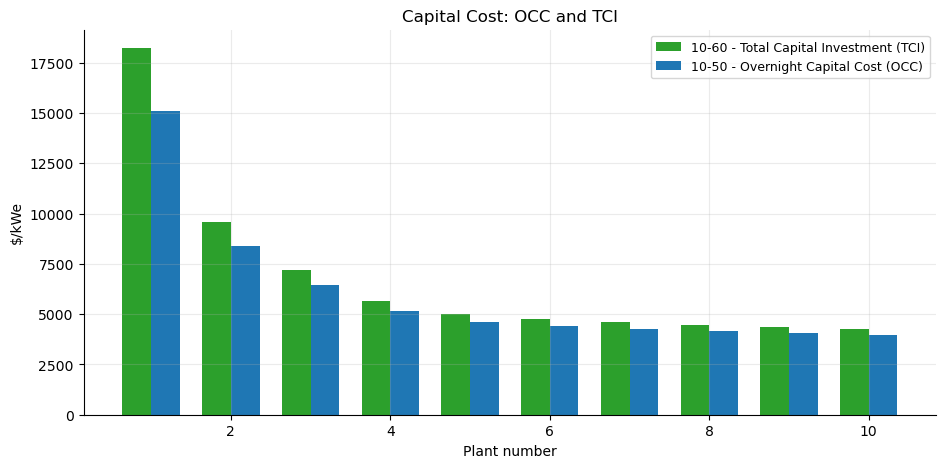

In [6]:
plot_capital_cost_panel(result, figsize=(11, 5))

### Total Construction Duration

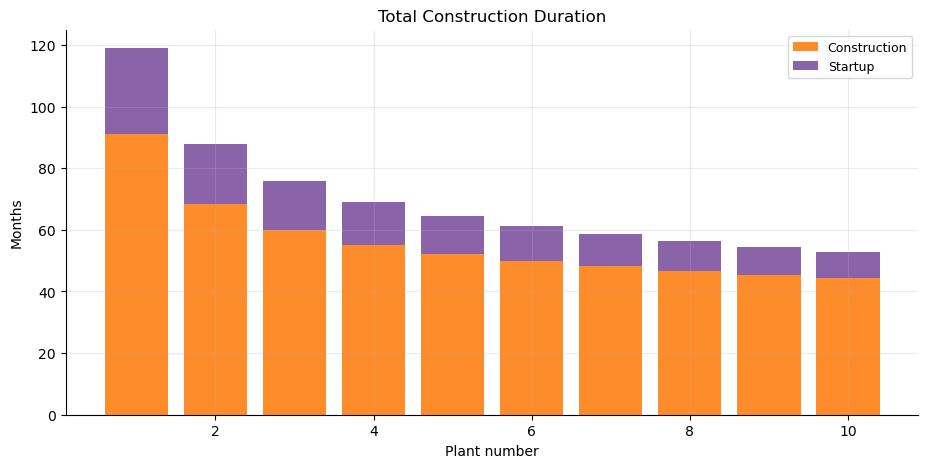

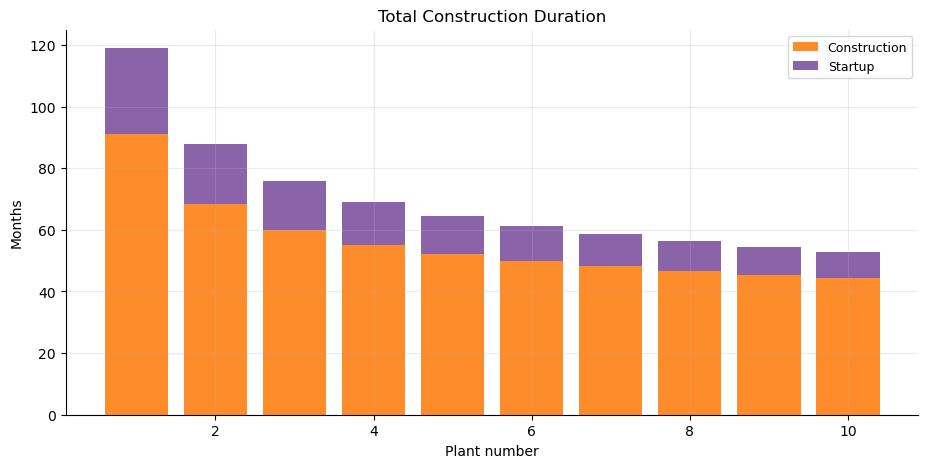

In [7]:
plot_duration_panel(result, figsize=(11, 5))

### TCI Breakdown

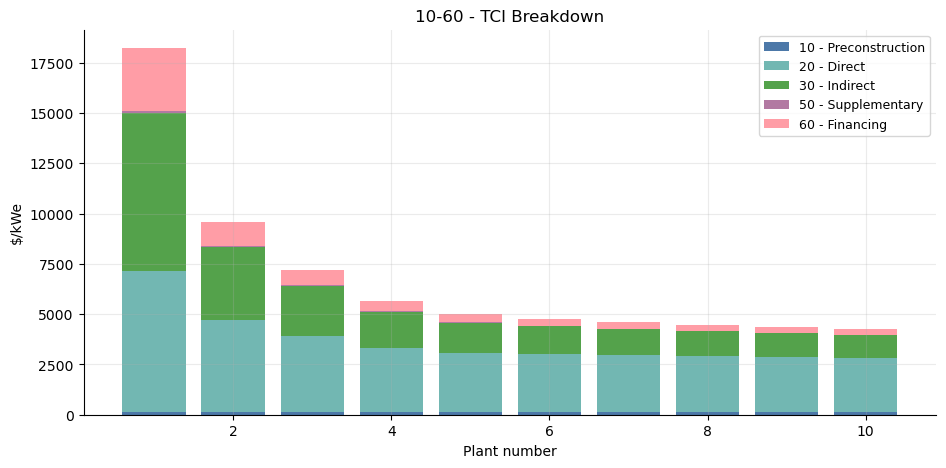

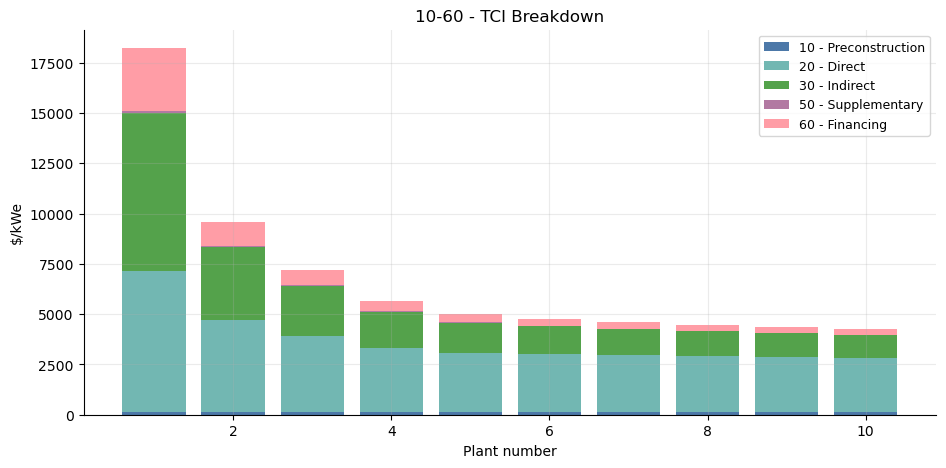

In [8]:
plot_tci_breakdown_panel(result, figsize=(11, 5))

### Sequential Construction Timeline

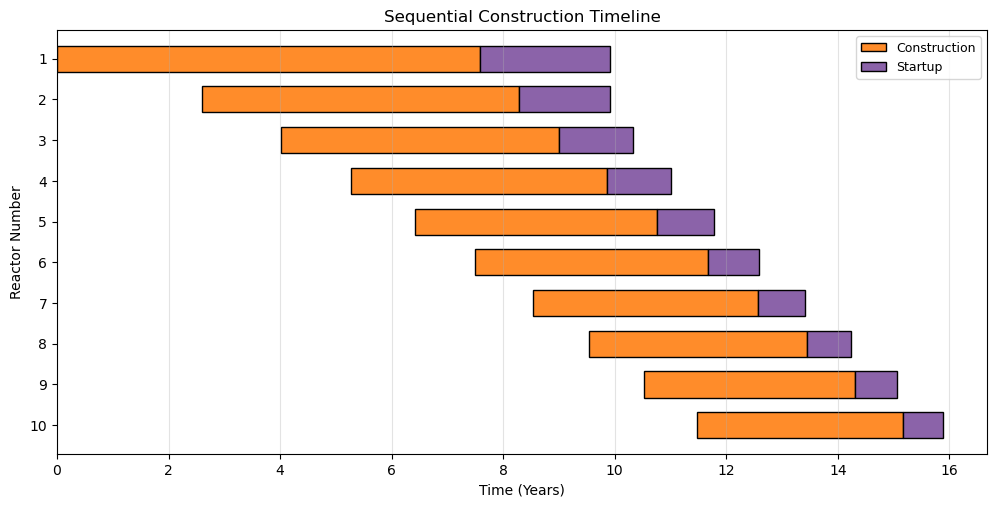

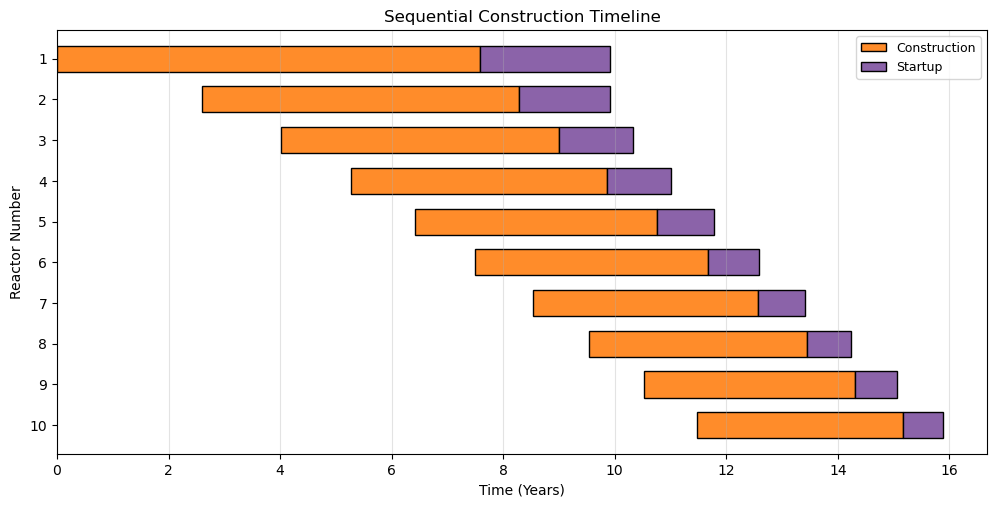

In [9]:
plot_timeline_panel(result, figsize=(12, 5.5))

### OCC Components

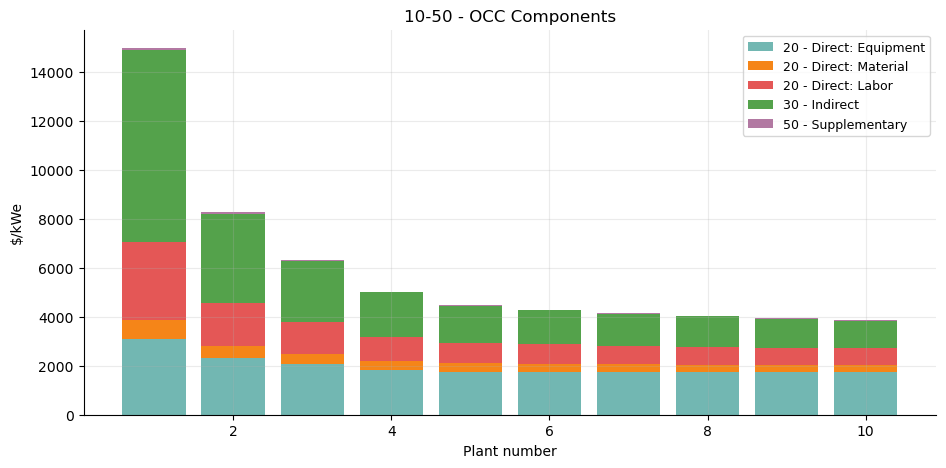

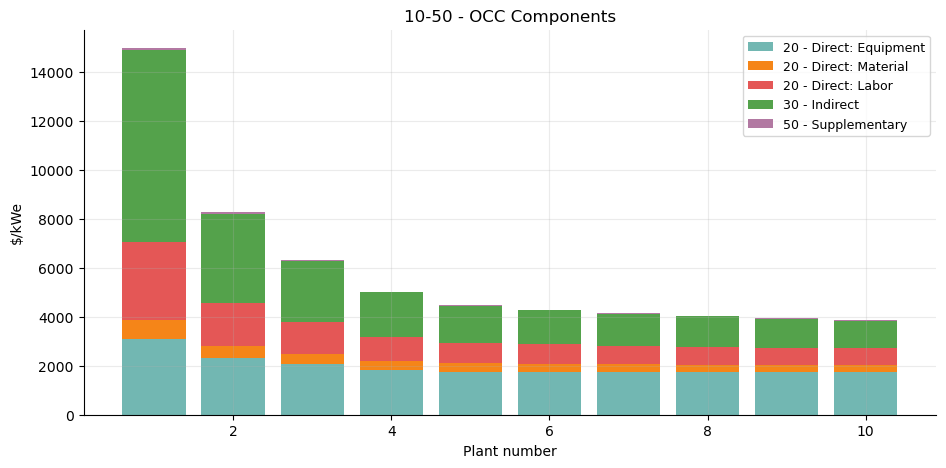

In [10]:
plot_occ_components_panel(result, figsize=(11, 5))

### OCC Waterfall

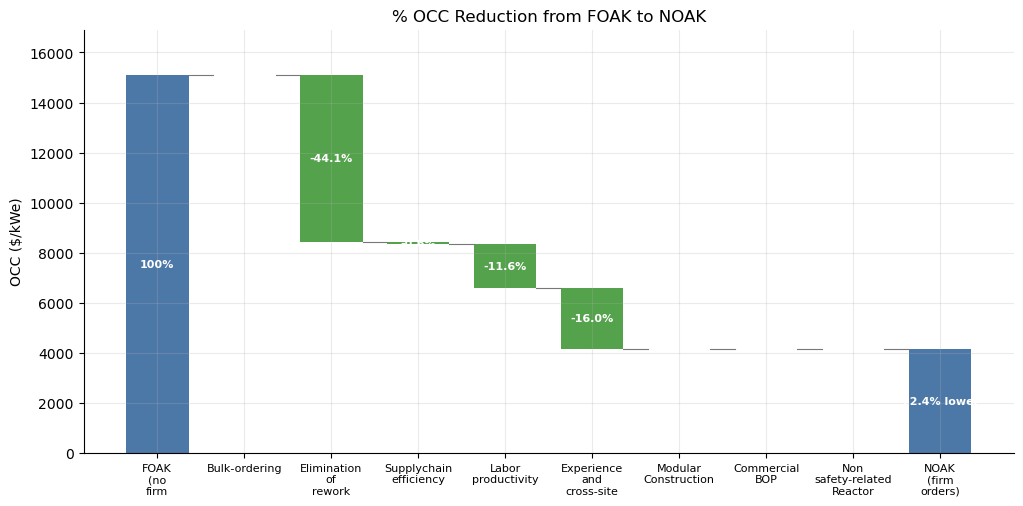

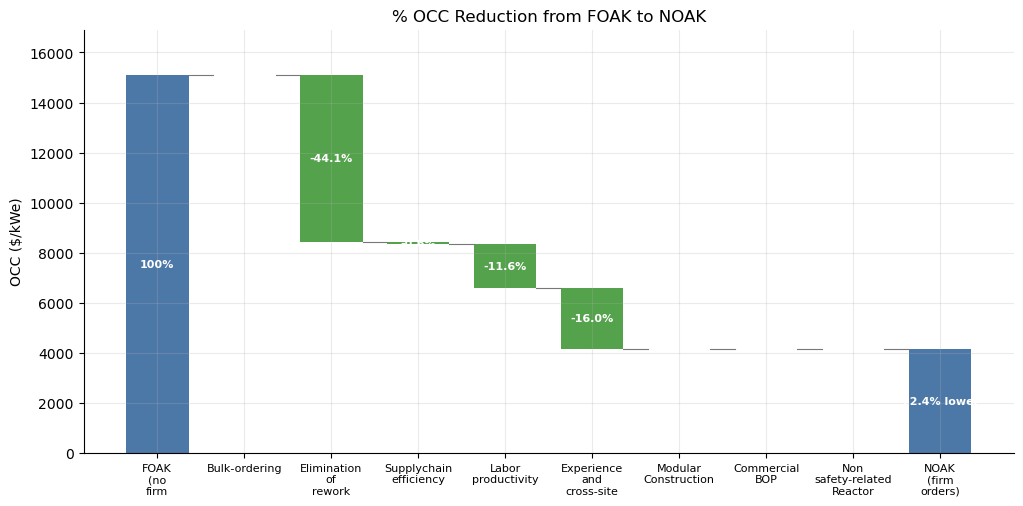

In [11]:
plot_waterfall_panel(result, figsize=(12, 5.5))

## 5. Result Tables

In [12]:
unit_results = results_to_dataframe(result)
unit_results.head(10)

,Plant number,OCC,Net OCC,TCI,NCI,Construction duration,Startup duration,Preconstruction costs,Direct costs,Direct costs: equipment,Direct costs: material,Direct costs: labor,Indirect costs,Supplementary costs,Financing costs,OCC reduction from FOAK
0,1,15102.810443,NaN,18234.073025,NaN,91.004408,28.000000,124.671799,7038.506078,3106.849817,755.457384,3176.198877,7864.842607,74.789959,3131.262582,0.000000
1,2,8386.778426,NaN,9565.411544,NaN,68.296591,19.600000,124.671799,4566.287313,2298.792328,503.342363,1764.152622,3651.116109,44.703205,1178.633118,44.468757
2,3,6446.141697,NaN,7176.449073,NaN,59.881944,15.909050,124.671799,3781.387394,2056.395235,423.468706,1301.523452,2504.073043,36.009462,730.307376,57.318264
3,4,5148.350759,NaN,5656.498517,NaN,55.162570,13.720000,124.671799,3193.246042,1834.310711,361.636080,997.299250,1800.237354,30.195565,508.147758,65.911307
4,5,4594.397226,NaN,5000.740454,NaN,52.184107,12.231700,124.671799,2947.740874,1759.009857,335.266514,853.464503,1494.270612,27.713941,406.343228,69.579190
5,6,4419.571794,NaN,4775.826212,NaN,50.008287,11.136335,124.671799,2879.570739,1751.702148,324.778453,803.090137,1388.398505,26.930751,356.254418,70.736759
6,7,4280.905062,NaN,4598.934958,NaN,48.239588,10.287107,124.671799,2824.549146,1745.555793,316.167311,762.826042,1305.374570,26.309546,318.029896,71.654911
7,8,4167.111521,NaN,4461.451506,NaN,46.758117,9.604000,124.671799,2778.731214,1740.255324,308.892768,729.583122,1237.908739,25.799769,294.339985,72.408370
8,9,4071.334201,NaN,4344.493258,NaN,45.489177,9.039209,124.671799,2739.678768,1735.598196,302.615223,701.465350,1181.612931,25.370702,273.159057,73.042539
9,10,3989.125787,NaN,4244.544003,NaN,44.383280,8.562190,124.671799,2705.787252,1731.446666,297.107949,677.232638,1133.664314,25.002422,255.418216,73.586864


In [13]:
levers_to_dataframe(result).head(10)

,N,Interest Rate,Design Completion,Design Maturity (0-2),Supplychain Proficiency (0-2),A/E Proficiency (0-2),Construction Proficiency (0-2),Cross Site Standardization,Modular Civil Construction,Commercial BOP,Non-Safety-Related RB,ITC Amount
0,1,6%,70%,1,0.50,0.50,0.50,,FALSE,FALSE,FALSE,0%
1,2,6%,100%,2,1.17,1.00,0.90,80%,FALSE,FALSE,FALSE,0%
2,3,6%,100%,2,1.83,1.50,1.30,80%,FALSE,FALSE,FALSE,0%
3,4,6%,100%,2,2.00,2.00,1.70,80%,FALSE,FALSE,FALSE,0%
4,5,6%,100%,2,2.00,2.00,2.00,80%,FALSE,FALSE,FALSE,0%
5,6,6%,100%,2,2.00,2.00,2.00,80%,FALSE,FALSE,FALSE,0%
6,7,6%,100%,2,2.00,2.00,2.00,80%,FALSE,FALSE,FALSE,0%
7,8,6%,100%,2,2.00,2.00,2.00,80%,FALSE,FALSE,FALSE,0%
8,9,6%,100%,2,2.00,2.00,2.00,80%,FALSE,FALSE,FALSE,0%
9,10,6%,100%,2,2.00,2.00,2.00,80%,FALSE,FALSE,FALSE,0%


In [14]:
waterfall_to_dataframe(result)

,label,absolute_change,cumulative_occ,kind
0,FOAK \n(no firm orders),15102.810443,15102.810443,total
1,Bulk-ordering,0.000000,15102.810443,change
2,Elimination of rework,-6667.420808,8435.389635,change
3,Supplychain efficiency,-88.179373,8347.210262,change
4,Labor productivity,-1759.181884,6588.028378,change
5,Experience and cross-site standardization,-2420.916857,4167.111521,change
6,Modular Construction,0.000000,4167.111521,change
7,Commercial BOP,0.000000,4167.111521,change
8,Non safety-related Reactor Building,0.000000,4167.111521,change
9,NOAK \n(firm orders),4167.111521,4167.111521,total


## 6. Compare Reactor Examples

In [15]:
summary_rows = []
for reactor_type in ["AP1000", "HTGR", "SFR"]:
    scenario = run_one_scenario(base_config(reactor_type), base_levers(reactor_type))
    summary_rows.append(
        {
            "Reactor": reactor_type,
            "Firm orders": scenario["Num_orders"],
            "NOAK plant": scenario["num_NOAK"],
            "FOAK OCC ($/kWe)": scenario["OCC_1"],
            "NOAK OCC ($/kWe)": scenario[f"OCC_{scenario['num_NOAK']}"],
            "OCC reduction (%)": occ_reduction_from_foak_to_noak(scenario),
            "Average OCC ($/kWe)": scenario["avg_OCC"],
            "Average TCI ($/kWe)": scenario["avg_TCI"],
            "Cumulative timeline (months)": scenario["cons_duration_cumulative_wz_startup"],
        }
    )

pd.DataFrame(summary_rows).round(2)

,Reactor,Firm orders,NOAK plant,FOAK OCC ($/kWe),NOAK OCC ($/kWe),OCC reduction (%),Average OCC ($/kWe),Average TCI ($/kWe),Cumulative timeline (months)
0,AP1000,10,8,15102.81,4167.11,72.41,6060.65,6805.84,190.56
1,HTGR,13,8,12765.15,3898.81,69.46,4953.45,6378.62,313.38
2,SFR,13,8,12269.26,4388.40,64.23,5298.32,6404.42,188.45
